# 🌲 Random Forest Model — Employee Attrition Prediction

**Author:** Ravindu  
**Project:** XGBoost vs Random Forest — Comparative Analysis  
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  

---

## Objective
Build, tune, and evaluate a **Random Forest** classifier to predict employee attrition (`Yes`/`No`).  
This notebook covers:
1. Data loading & quick inspection
2. Train / validation / test split
3. Baseline Random Forest
4. Hyperparameter tuning (RandomizedSearchCV)
5. Final model evaluation (metrics + visualisations)
6. Feature importance analysis
7. Key findings & comparison notes


## 1. Imports & Configuration

In [3]:
# ── Standard library ────────────────────────────────────────────────────────
import warnings
import os

warnings.filterwarnings('ignore')

# ── Data handling ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance

# ── Scipy ─────────────────────────────────────────────────────────────────────
from scipy.stats import randint, uniform

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

print('All libraries loaded successfully ✅')

All libraries loaded successfully ✅


## 2. Load the Pre-processed Dataset

In [11]:
# ── Path is relative to the notebooks/ folder ─────────────────────────────────
DATA_PATH = os.path.join('..', 'data', 'Processed', 'cleaned_dataset.csv')

df = pd.read_csv(DATA_PATH)
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1})

print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


In [12]:
# ── Quick sanity check ───────────────────────────────────────────────────────
print('--- Data Types ---')
print(df.dtypes.value_counts())

print('\n--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values 🎉')

print('\n--- Target Distribution ---')
target_counts = df['Attrition'].value_counts()
print(target_counts)
print(f'\nAttrition rate: {target_counts[1] / len(df) * 100:.1f}%')

--- Data Types ---
int64     24
object     7
Name: count, dtype: int64

--- Missing Values ---
No missing values 🎉

--- Target Distribution ---
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.1%


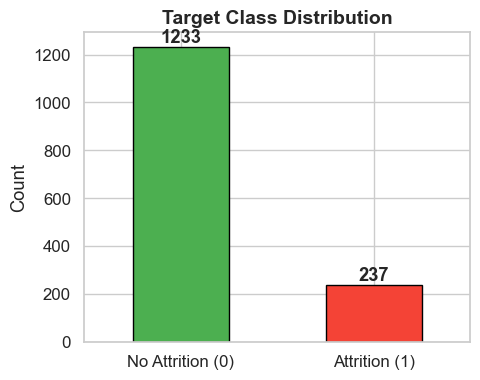

In [6]:
# ── Class imbalance visualisation ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4CAF50', '#F44336']
target_counts.rename({0: 'No Attrition', 1: 'Attrition'}).plot(
    kind='bar', ax=ax, color=colors, edgecolor='black', width=0.5
)
ax.set_title('Target Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Attrition (0)', 'Attrition (1)'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Feature & Target Separation → Train / Test Split

In [18]:
TARGET = 'Attrition'

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# ── One-hot encode categorical columns for sklearn compatibility ─────────────
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# ── Convert any boolean columns to int after encoding ───────────────────────
bool_cols = X.select_dtypes(include='bool').columns.tolist()
X[bool_cols] = X[bool_cols].astype(int)

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'\nCategorical columns encoded: {cat_cols}')
print(f'Boolean columns converted to int: {bool_cols}')

Features : 51
Samples  : 1470

Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Boolean columns converted to int: ['BusinessTravel_Non-Travel', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single', 'OverTime_No', 'OverTime_Yes']


In [21]:
# ── Stratified 80 / 20 split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # preserve class ratio
)

print(f'Training set  : {X_train.shape[0]} samples')
print(f'Test set      : {X_test.shape[0]}  samples')
print(f'\nTrain attrition rate : {y_train.mean()*100:.1f}%')
print(f'Test  attrition rate : {y_test.mean()*100:.1f}%')

Training set  : 1176 samples
Test set      : 294  samples

Train attrition rate : 16.2%
Test  attrition rate : 16.0%


## 4. Baseline Random Forest

In [22]:
# ── Baseline model with default hyperparameters ───────────────────────────────
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_base  = rf_baseline.predict(X_test)
y_proba_base = rf_baseline.predict_proba(X_test)[:, 1]

print('=== Baseline Random Forest ===')
print(classification_report(y_test, y_pred_base, target_names=['No Attrition', 'Attrition']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba_base):.4f}')

=== Baseline Random Forest ===
              precision    recall  f1-score   support

No Attrition       0.86      0.98      0.92       247
   Attrition       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294

ROC-AUC : 0.7843


In [23]:
# ── 5-fold stratified cross-validation on baseline ────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_roc  = cross_val_score(rf_baseline, X_train, y_train, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_f1   = cross_val_score(rf_baseline, X_train, y_train, cv=cv, scoring='f1',       n_jobs=-1)
cv_acc  = cross_val_score(rf_baseline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'CV ROC-AUC : {cv_roc.mean():.4f} ± {cv_roc.std():.4f}')
print(f'CV F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')
print(f'CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')

CV ROC-AUC : 0.7995 ± 0.0317
CV F1      : 0.3153  ± 0.0777
CV Accuracy: 0.8631 ± 0.0073


## 5. Hyperparameter Tuning with RandomizedSearchCV

In [24]:
# ── Search space ──────────────────────────────────────────────────────────────
param_dist = {
    'n_estimators'      : randint(100, 600),
    'max_depth'         : [None, 5, 10, 15, 20, 25],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2', 0.5, 0.7],
    'class_weight'      : ['balanced', 'balanced_subsample', None],
    'bootstrap'         : [True, False],
    'criterion'         : ['gini', 'entropy'],
}

rf_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = param_dist,
    n_iter     = 80,           # number of random combinations to try
    cv         = cv,
    scoring    = 'roc_auc',    # optimise for AUC (handles imbalance better)
    refit      = True,
    verbose    = 1,
    random_state = RANDOM_STATE,
    n_jobs     = -1
)

rf_search.fit(X_train, y_train)

print('\n✅ Tuning complete!')
print(f'Best CV ROC-AUC : {rf_search.best_score_:.4f}')
print('Best Parameters :')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

✅ Tuning complete!
Best CV ROC-AUC : 0.8149
Best Parameters :
  bootstrap: True
  class_weight: None
  criterion: gini
  max_depth: 15
  max_features: log2
  min_samples_leaf: 3
  min_samples_split: 6
  n_estimators: 185


## 6. Tuned Model Evaluation

In [25]:
# ── Best estimator from search ────────────────────────────────────────────────
rf_tuned = rf_search.best_estimator_

y_pred_tuned  = rf_tuned.predict(X_test)
y_proba_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# ── Metrics ──────────────────────────────────────────────────────────────────
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1-Score' : f1_score(y_test, y_pred_tuned, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_tuned),
    'PR-AUC'   : average_precision_score(y_test, y_proba_tuned),
}

print('=== Tuned Random Forest — Test Set Metrics ===')
for name, val in metrics.items():
    print(f'  {name:<12}: {val:.4f}')

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred_tuned, target_names=['No Attrition', 'Attrition']))

=== Tuned Random Forest — Test Set Metrics ===
  Accuracy    : 0.8401
  Precision   : 0.5000
  Recall      : 0.0851
  F1-Score    : 0.1455
  ROC-AUC     : 0.7804
  PR-AUC      : 0.4423

--- Classification Report ---
              precision    recall  f1-score   support

No Attrition       0.85      0.98      0.91       247
   Attrition       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



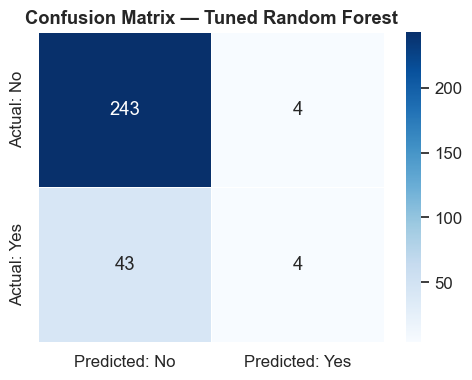

True Negatives  : 243
False Positives : 4
False Negatives : 43
True Positives  : 4


In [26]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tuned)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Yes'],
    yticklabels=['Actual: No', 'Actual: Yes'],
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix — Tuned Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  : {tn}')
print(f'False Positives : {fp}')
print(f'False Negatives : {fn}')
print(f'True Positives  : {tp}')

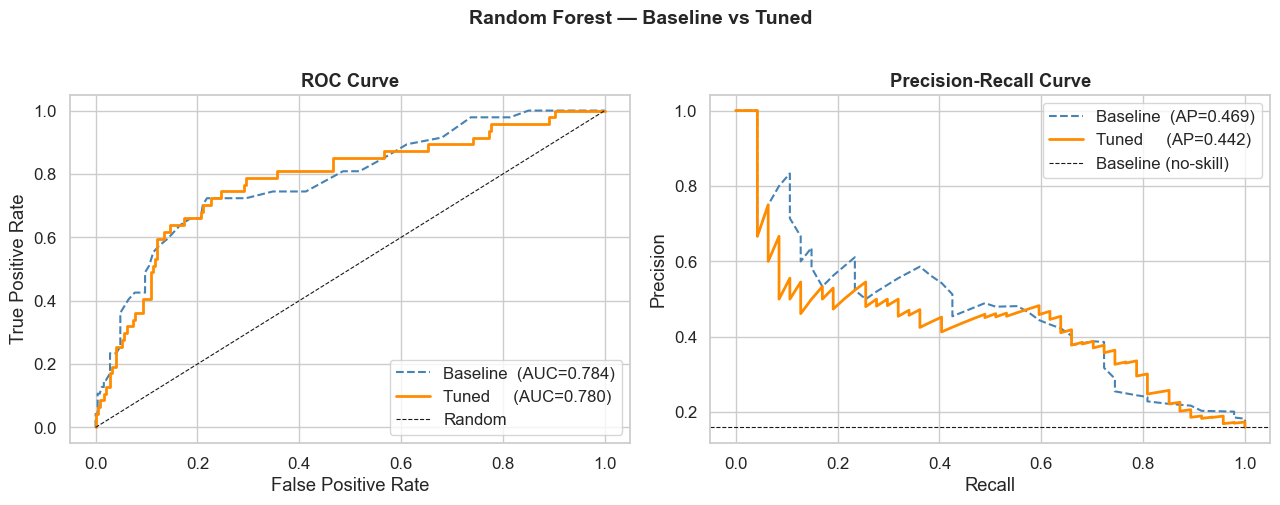

In [27]:
# ── ROC & Precision-Recall curves ─────────────────────────────────────────────
fpr_base,  tpr_base,  _ = roc_curve(y_test, y_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

prec_base,  rec_base,  _ = precision_recall_curve(y_test, y_proba_base)
prec_tuned, rec_tuned, _ = precision_recall_curve(y_test, y_proba_tuned)

auc_base  = roc_auc_score(y_test, y_proba_base)
auc_tuned = roc_auc_score(y_test, y_proba_tuned)
ap_base   = average_precision_score(y_test, y_proba_base)
ap_tuned  = average_precision_score(y_test, y_proba_tuned)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_base,  tpr_base,  label=f'Baseline  (AUC={auc_base:.3f})',  lw=1.5, linestyle='--', color='steelblue')
axes[0].plot(fpr_tuned, tpr_tuned, label=f'Tuned     (AUC={auc_tuned:.3f})', lw=2.0, color='darkorange')
axes[0].plot([0,1],[0,1], 'k--', lw=0.8, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend()

# PR
axes[1].plot(rec_base,  prec_base,  label=f'Baseline  (AP={ap_base:.3f})',  lw=1.5, linestyle='--', color='steelblue')
axes[1].plot(rec_tuned, prec_tuned, label=f'Tuned     (AP={ap_tuned:.3f})', lw=2.0, color='darkorange')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', lw=0.8, label='Baseline (no-skill)')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend()

plt.suptitle('Random Forest — Baseline vs Tuned', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

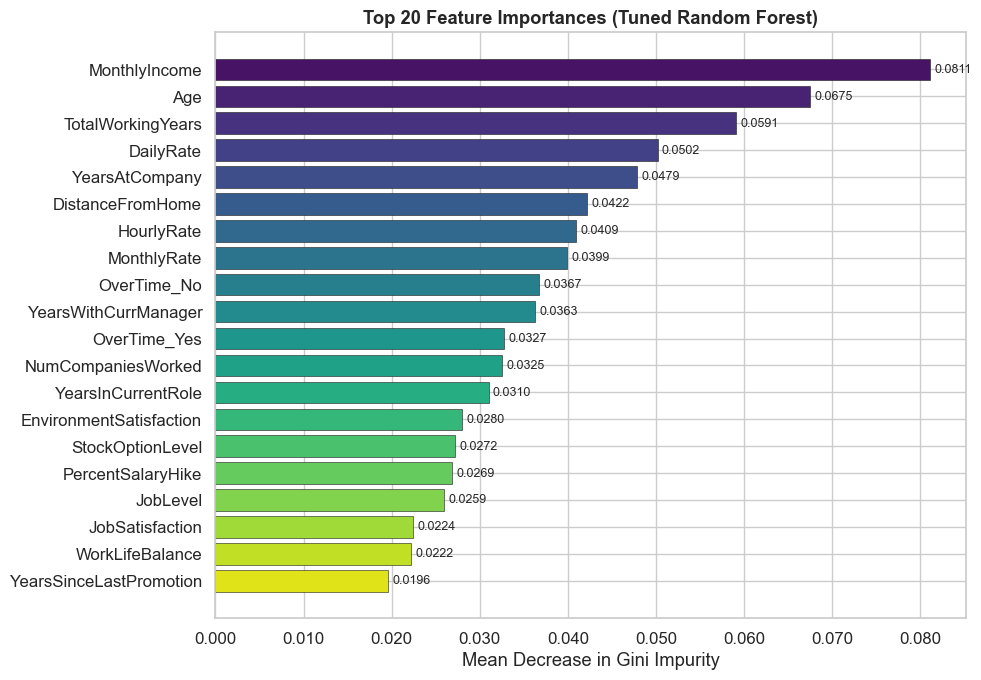


Top 10 features:
MonthlyIncome           0.081073
Age                     0.067497
TotalWorkingYears       0.059135
DailyRate               0.050171
YearsAtCompany          0.047850
DistanceFromHome        0.042192
HourlyRate              0.040922
MonthlyRate             0.039895
OverTime_No             0.036684
YearsWithCurrManager    0.036252


In [28]:
# ── Gini-based (built-in) importance ──────────────────────────────────────────
feat_imp = pd.Series(
    rf_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

TOP_N = 20
top_features = feat_imp.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('viridis', TOP_N)
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors[::-1], edgecolor='k', linewidth=0.4)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title(f'Top {TOP_N} Feature Importances (Tuned Random Forest)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{w:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(top_features.head(10).to_string())

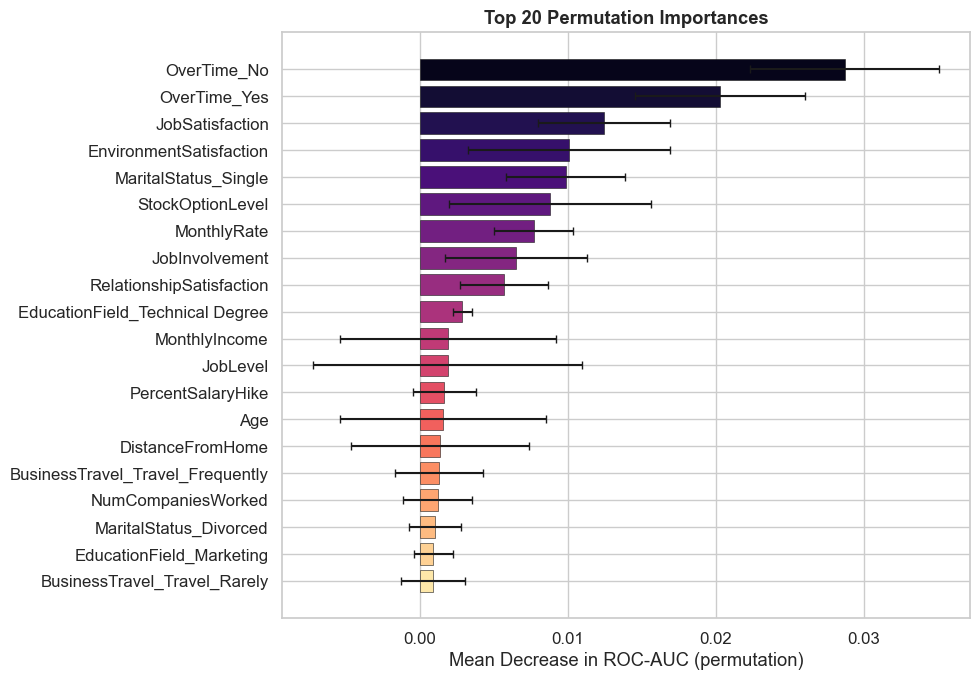

In [29]:
# ── Permutation importance (model-agnostic, more reliable) ───────────────────
perm_result = permutation_importance(
    rf_tuned, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    'feature'   : X.columns,
    'importance': perm_result.importances_mean,
    'std'       : perm_result.importances_std
}).sort_values('importance', ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    perm_imp['feature'][::-1],
    perm_imp['importance'][::-1],
    xerr=perm_imp['std'][::-1],
    color=sns.color_palette('magma', TOP_N)[::-1],
    edgecolor='k', linewidth=0.4, capsize=3
)
ax.set_xlabel('Mean Decrease in ROC-AUC (permutation)')
ax.set_title(f'Top {TOP_N} Permutation Importances', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Tuning Progress — Search Results

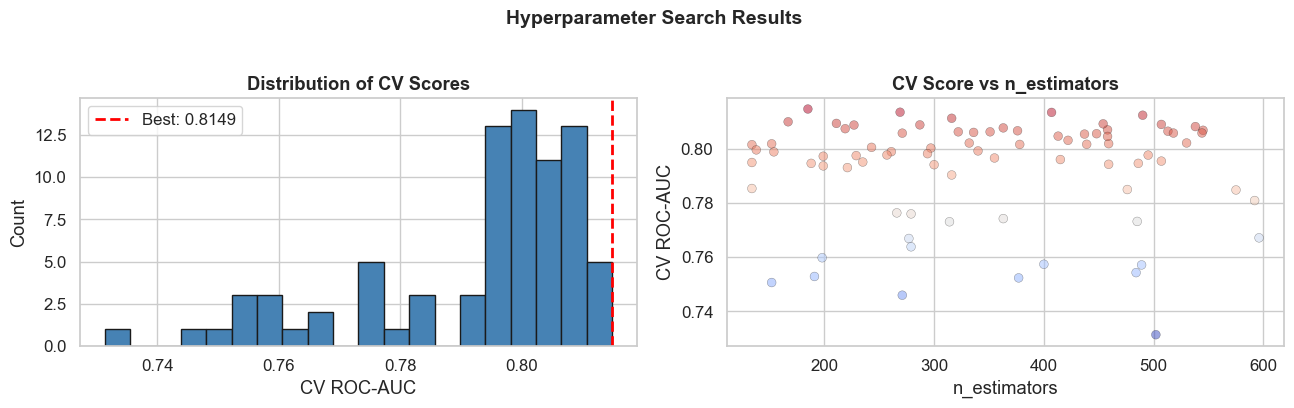

In [30]:
# ── Distribution of CV scores across candidates ───────────────────────────────
cv_results_df = pd.DataFrame(rf_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Score distribution
axes[0].hist(cv_results_df['mean_test_score'], bins=20, color='steelblue', edgecolor='k')
axes[0].axvline(rf_search.best_score_, color='red', linestyle='--', lw=2, label=f'Best: {rf_search.best_score_:.4f}')
axes[0].set_xlabel('CV ROC-AUC'); axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of CV Scores', fontweight='bold'); axes[0].legend()

# Scores vs n_estimators
axes[1].scatter(
    cv_results_df['param_n_estimators'].astype(int),
    cv_results_df['mean_test_score'],
    alpha=0.5, c=cv_results_df['mean_test_score'],
    cmap='coolwarm', edgecolors='k', linewidths=0.3, s=40
)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('CV ROC-AUC')
axes[1].set_title('CV Score vs n_estimators', fontweight='bold')

plt.suptitle('Hyperparameter Search Results', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Baseline vs Tuned — Side-by-Side Comparison

=== Baseline vs Tuned Random Forest ===
           Baseline  Tuned RF  Δ Improvement
Metric                                      
Accuracy     0.8503    0.8401        -0.0102
Precision    0.6364    0.5000        -0.1364
Recall       0.1489    0.0851        -0.0638
F1-Score     0.2414    0.1455        -0.0959
ROC-AUC      0.7843    0.7804        -0.0039
PR-AUC       0.4693    0.4423        -0.0270


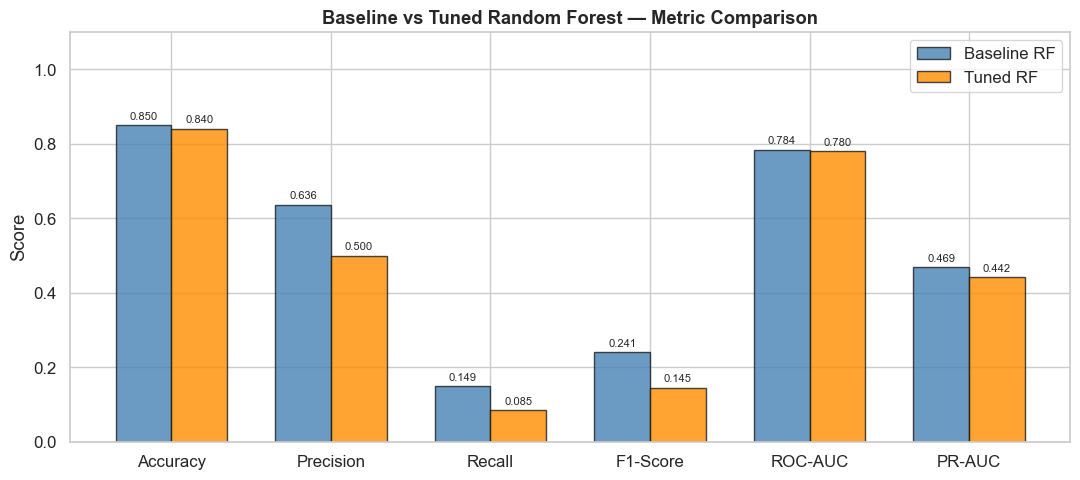

In [31]:
comparison = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC'],
    'Baseline' : [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base, zero_division=0),
        recall_score(y_test, y_pred_base, zero_division=0),
        f1_score(y_test, y_pred_base, zero_division=0),
        roc_auc_score(y_test, y_proba_base),
        average_precision_score(y_test, y_proba_base),
    ],
    'Tuned RF' : list(metrics.values()),
})
comparison['Δ Improvement'] = comparison['Tuned RF'] - comparison['Baseline']
comparison = comparison.set_index('Metric')
comparison = comparison.round(4)

print('=== Baseline vs Tuned Random Forest ===')
print(comparison.to_string())

# Radar-style bar chart
metrics_list = comparison.index.tolist()
x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, comparison['Baseline'], width, label='Baseline RF', color='steelblue',   edgecolor='k', alpha=0.8)
ax.bar(x + width/2, comparison['Tuned RF'], width, label='Tuned RF',    color='darkorange', edgecolor='k', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Random Forest — Metric Comparison', fontweight='bold')
ax.legend()
for rect in ax.patches:
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, h + 0.01, f'{h:.3f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Decision Threshold Optimisation

Default threshold (0.5) F1  : 0.1455
Optimal threshold (0.26) F1: 0.5333


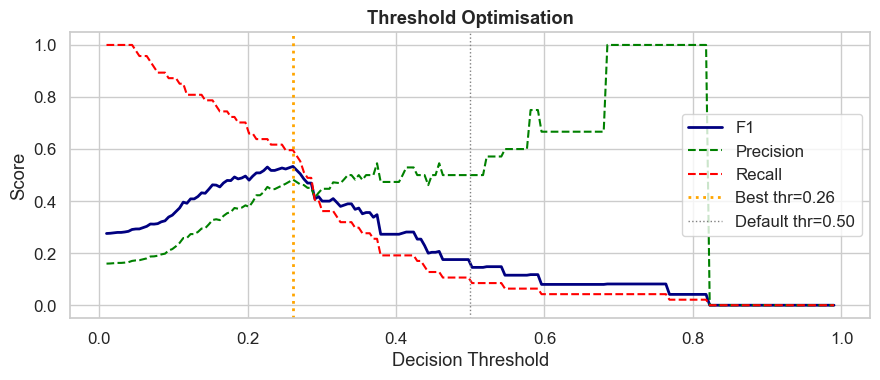

In [32]:
# ── Sweep thresholds and find optimal F1 ──────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores, prec_scores, rec_scores = [], [], []

for thr in thresholds:
    preds = (y_proba_tuned >= thr).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_ix  = np.argmax(f1_scores)
best_thr = thresholds[best_ix]
best_f1  = f1_scores[best_ix]

print(f'Default threshold (0.5) F1  : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}')
print(f'Optimal threshold ({best_thr:.2f}) F1: {best_f1:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1_scores,   label='F1',       color='navy',   lw=2)
ax.plot(thresholds, prec_scores, label='Precision', color='green',  lw=1.5, linestyle='--')
ax.plot(thresholds, rec_scores,  label='Recall',    color='red',    lw=1.5, linestyle='--')
ax.axvline(best_thr, color='orange', lw=2, linestyle=':', label=f'Best thr={best_thr:.2f}')
ax.axvline(0.5,      color='grey',   lw=1, linestyle=':', label='Default thr=0.50')
ax.set_xlabel('Decision Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Key Findings & Summary

In [33]:
print('=' * 60)
print('      RANDOM FOREST — KEY FINDINGS SUMMARY')
print('=' * 60)

print(f"""
Dataset
  • Total samples   : {len(df)}
  • Features        : {X.shape[1]}
  • Attrition rate  : {y.mean() * 100:.1f}%  (class imbalance present)

Model Performance — Tuned RF on Hold-out Test Set
  • Accuracy   : {metrics['Accuracy']:.4f}
  • Precision  : {metrics['Precision']:.4f}
  • Recall     : {metrics['Recall']:.4f}
  • F1-Score   : {metrics['F1-Score']:.4f}
  • ROC-AUC    : {metrics['ROC-AUC']:.4f}
  • PR-AUC     : {metrics['PR-AUC']:.4f}

Tuning Insights
  • RandomizedSearchCV (80 iterations, 5-fold CV, scored on ROC-AUC)
  • Best parameters: {rf_search.best_params_}
  • Optimal decision threshold: {best_thr:.2f}  (F1={best_f1:.4f})

Top 5 Attrition Predictors (Gini importance)
""")

for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f'  {i}. {feat:<35} {imp:.4f}')

print("""
Comparison Notes (vs XGBoost)
  • RF is easier to tune, robust to overfitting due to bagging.
  • XGBoost typically yields higher AUC on imbalanced data due
    to its boosting (sequential error correction) mechanism.
  • RF offers better interpretability via feature importances.
  • Both models benefit from class_weight / scale_pos_weight
    to handle the minority (Attrition=Yes) class.
""")
print('=' * 60)

      RANDOM FOREST — KEY FINDINGS SUMMARY

Dataset
  • Total samples   : 1470
  • Features        : 51
  • Attrition rate  : 16.1%  (class imbalance present)

Model Performance — Tuned RF on Hold-out Test Set
  • Accuracy   : 0.8401
  • Precision  : 0.5000
  • Recall     : 0.0851
  • F1-Score   : 0.1455
  • ROC-AUC    : 0.7804
  • PR-AUC     : 0.4423

Tuning Insights
  • RandomizedSearchCV (80 iterations, 5-fold CV, scored on ROC-AUC)
  • Best parameters: {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 185}
  • Optimal decision threshold: 0.26  (F1=0.5333)

Top 5 Attrition Predictors (Gini importance)

  1. MonthlyIncome                       0.0811
  2. Age                                 0.0675
  3. TotalWorkingYears                   0.0591
  4. DailyRate                           0.0502
  5. YearsAtCompany                      0.0479

Comparison Notes (vs XGBoost)

## 8. Export Model for Evaluation & Feature Importance Analysis

Saving the tuned model to the `models/` directory so it can be evaluated and analyzed by other team members without retraining.

In [34]:
import joblib
import os

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# Export the final tuned model
model_path = '../models/random_forest_tuned.joblib'
joblib.dump(rf_tuned, model_path)

print(f'Model successfully saved to {model_path}')

Model successfully saved to ../models/random_forest_tuned.joblib


---
**End of Notebook** | Author: Ravindu | Random Forest — Employee Attrition Prediction